In [1]:
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting

corpus = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]} without {X[InIdiom=Yes];X[Idiom=Yes]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="coverage"
)

connected to port: 58696


Number of matches after filtering: 11701


In [2]:
X = corpus.feature_matrix
print(X.shape)

(129, 298)


In [182]:
import numpy as np
with open ('x_298dims.npy', 'wb')as f:
    np.save(f, X)

In [3]:
import pandas as pd
import numpy as np
# Convert X to a DataFrame for easier manipulation 
X_df = pd.DataFrame(X, columns=[corpus.idx2feature(idx) for idx in range(X.shape[1])])

# Calculate the correlation matrix
correlation_matrix = X_df.corr().abs()  # Absolute value of correlations

# Identify highly correlated features (correlation > 0.9)
threshold = 0.9
highly_correlated = np.where(correlation_matrix > threshold)
correlated_pairs = [
    (correlation_matrix.index[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j])
    for i, j in zip(*highly_correlated)
    if i != j and i < j  # Avoid self-correlation and duplicate pairs
]

# Create a set of features to remove
features_to_remove_corr = set()
for feature1, feature2, correlation in correlated_pairs:
    # Decide which feature to remove (keep the one with higher variance)
    if X_df[feature1].var() > X_df[feature2].var():
        features_to_remove_corr.add(feature2)
    else:
        features_to_remove_corr.add(feature1)

# Map features to indices using corpus.feature2idx
indices_to_remove_corr = [corpus.feature2idx(feature) for feature in features_to_remove_corr]
indices_to_keep = [i for i in range(X.shape[1]) if i not in indices_to_remove_corr]

# Remove the columns from X
X_cleaned = np.delete(X, list(indices_to_remove_corr), axis=1)

print(f"Original shape of X: {X.shape}")
print(f"Shape of X after removing highly correlated features: {X_cleaned.shape}")

Original shape of X: (129, 298)
Shape of X after removing highly correlated features: (129, 227)


In [4]:
features_to_remove_corr

{'node:X:child:Emph=No',
 'node:X:child:ExtPos=ADP',
 'node:X:child:ExtPos=NOUN',
 'node:X:child:Gender=Fem',
 'node:X:child:Gender=Masc',
 'node:X:child:Mood=Ind',
 'node:X:child:Mood=Sub',
 'node:X:child:Number__psor=Sing',
 'node:X:child:Person__psor=3',
 'node:X:child:PronType=Art',
 'node:X:child:PronType=Dem',
 'node:X:child:PronType=Int',
 'node:X:child:Reflex=Yes',
 'node:X:child:Subject=OblRaising',
 'node:X:child:Subject=SubjRaising',
 'node:X:child:VerbForm=Inf',
 'node:X:child:VerbForm=Part',
 'node:X:child:Voice=Pass',
 'node:X:child:rel_shallow=acl:relcl',
 'node:X:child:rel_shallow=advcl:cleft',
 'node:X:child:rel_shallow=advmod',
 'node:X:child:rel_shallow=case',
 'node:X:child:rel_shallow=cc',
 'node:X:child:rel_shallow=cop',
 'node:X:child:rel_shallow=dep',
 'node:X:child:rel_shallow=goeswith',
 'node:X:child:rel_shallow=orphan',
 'node:X:child:rel_shallow=punct',
 'node:X:child:upos=ADV',
 'node:X:child:upos=CCONJ',
 'node:X:child:upos=SCONJ',
 'node:X:next:Emph=No',

In [4]:
print("Highly correlated pairs and their correlation values:")
for feature1, feature2, correlation in correlated_pairs:
    print(f"{feature1} and {feature2}: {correlation:.2f}")

Highly correlated pairs and their correlation values:
node:X:child:Emph=No and node:X:child:PronType=Prs: 0.95
node:X:child:ExtPos=ADP and node:X:child:rel_shallow=orphan: 1.00
node:X:child:ExtPos=ADP and node:X:own:rel_shallow=appos: 0.99
node:X:child:ExtPos=NOUN and node:X:child:upos=SYM: 1.00
node:X:child:Gender=Fem and node:X:child:upos=NOUN: 0.90
node:X:child:Gender=Masc and node:X:child:upos=NOUN: 0.96
node:X:child:Mood=Ind and node:X:child:VerbForm=Fin: 0.99
node:X:child:Mood=Sub and node:X:child:Subject=Generic: 0.98
node:X:child:Mood=Sub and node:X:child:Subject=OblRaising: 0.96
node:X:child:Number__psor=Sing and node:X:child:Person__psor=3: 1.00
node:X:child:Number__psor=Sing and node:X:child:Poss=Yes: 1.00
node:X:child:Person__psor=3 and node:X:child:Poss=Yes: 1.00
node:X:child:PronType=Art and node:X:child:upos=DET: 1.00
node:X:child:PronType=Dem and node:X:child:upos=PRON: 0.91
node:X:child:PronType=Int and node:X:own:PronType=Rel: 1.00
node:X:child:PronType=Int and node:X

In [6]:
correlated_pairs_sorted = sorted(correlated_pairs, key=lambda x: abs(x[2]), reverse=True)

print("\\begin{longtable}{lll}")
print("\\caption{Highly correlated feature pairs and their correlation values}\\\\")
print("\\toprule")
print("Feature 1 & Feature 2 & Correlation\\\\")
print("\\midrule")
print("\\endfirsthead")
print("\\toprule")
print("Feature 1 & Feature 2 & Correlation\\\\")
print("\\midrule")
print("\\endhead")

for feature1, feature2, correlation in correlated_pairs_sorted:
    print(f"{feature1} & {feature2} & {correlation:.2f}\\\\")
print("\\bottomrule")
print("\\end{longtable}")

\begin{longtable}{lll}
\caption{Highly correlated feature pairs and their correlation values}\\
\toprule
Feature 1 & Feature 2 & Correlation\\
\midrule
\endfirsthead
\toprule
Feature 1 & Feature 2 & Correlation\\
\midrule
\endhead
node:X:child:ExtPos=ADP & node:X:child:rel_shallow=orphan & 1.00\\
node:X:child:ExtPos=NOUN & node:X:child:upos=SYM & 1.00\\
node:X:child:Number__psor=Sing & node:X:child:Person__psor=3 & 1.00\\
node:X:child:Number__psor=Sing & node:X:child:Poss=Yes & 1.00\\
node:X:child:Person__psor=3 & node:X:child:Poss=Yes & 1.00\\
node:X:child:PronType=Art & node:X:child:upos=DET & 1.00\\
node:X:child:PronType=Int & node:X:own:PronType=Rel & 1.00\\
node:X:child:Reflex=Yes & node:X:child:rel_shallow=dep & 1.00\\
node:X:child:Reflex=Yes & node:X:prev:PronType=Exc & 1.00\\
node:X:child:rel_shallow=advcl:cleft & node:X:child:rel_shallow=expl:subj & 1.00\\
node:X:child:rel_shallow=cop & node:X:child:upos=AUX & 1.00\\
node:X:child:rel_shallow=dep & node:X:prev:PronType=Exc & 1.

Now we've removed highly correlated features, let's remove those that are very rare or very common.

In [7]:
import plotly.graph_objects as go
frequency_matrix = corpus.co_occurrence_matrix
column_sums = np.sum(frequency_matrix, axis=0)

frequency_df = pd.DataFrame({
    'Feature': [corpus.idx2feature(i) for i in indices_to_keep],
    'Frequency': column_sums[indices_to_keep]
})

In [8]:
frequency_df

,Feature,Frequency
0,node:X:child:Definite=Def,28.0
1,node:X:child:Definite=Ind,27.0
2,node:X:child:Emph=Yes,5.0
3,node:X:child:ExtPos=ADV,66.0
4,node:X:child:ExtPos=CCONJ,1.0
...,...,...
222,node:X:prev:upos=PROPN,252.0
223,node:X:prev:upos=PUNCT,958.0
224,node:X:prev:upos=SCONJ,52.0
225,node:X:prev:upos=VERB,2882.0


In [10]:
# Sort by frequency descending
frequency_df_sorted = frequency_df.sort_values(by="Frequency", ascending=False)

print("\\begin{longtable}{lr}")
print("\\caption{Feature frequencies}\\\\")
print("\\toprule")
print("Feature & Frequency\\\\")
print("\\midrule")
print("\\endfirsthead")
print("\\toprule")
print("Feature & Frequency\\\\")
print("\\midrule")
print("\\endhead")

for _, row in frequency_df_sorted.iterrows():
    feature = row['Feature']
    freq = row['Frequency']
    if freq < 11 or freq > 4500:
        feature = f"\\textit{{{feature}}}"
    print(f"{feature} & {freq}\\\\")
print("\\bottomrule")
print("\\end{longtable}")

\begin{longtable}{lr}
\caption{Feature frequencies}\\
\toprule
Feature & Frequency\\
\midrule
\endfirsthead
\toprule
Feature & Frequency\\
\midrule
\endhead
\textit{node:X:own:rel_shallow=advmod} & 11124.0\\
\textit{node:X:parent:position=after} & 7796.0\\
\textit{node:X:parent:Number=Sing} & 7511.0\\
\textit{node:X:parent:upos=VERB} & 6928.0\\
\textit{node:X:prev:Number=Sing} & 5367.0\\
\textit{node:X:next:Number=Sing} & 4565.0\\
node:X:prev:VerbForm=Fin & 4000.0\\
node:X:parent:Gender=Masc & 3934.0\\
node:X:parent:position=before & 3905.0\\
node:X:parent:VerbForm=Fin & 3753.0\\
node:X:parent:Tense=Pres & 3178.0\\
node:X:own:Polarity=Neg & 3164.0\\
node:X:prev:upos=VERB & 2882.0\\
node:X:parent:Tense=Past & 2629.0\\
node:X:next:upos=ADP & 2617.0\\
node:X:next:Gender=Masc & 2579.0\\
node:X:parent:Number=Plur & 2456.0\\
node:X:next:upos=VERB & 2238.0\\
node:X:parent:Gender=Fem & 2133.0\\
node:X:prev:Number=Plur & 1949.0\\
node:X:prev:upos=AUX & 1925.0\\
node:X:prev:Gender=Masc & 1905.0\

In [17]:
import plotly.express as px

# Add an index column to the DataFrame
frequency_df_sorted = frequency_df.sort_values(by="Frequency", ascending=True).reset_index(drop=True)
frequency_df_sorted["Index"] = frequency_df_sorted.index

# Create the bar plot
fig = px.bar(
    frequency_df_sorted,
    x="Index",  # Use the index as the x-axis
    y="Frequency",  # Use the frequency as the y-axis
    hover_data={"Feature": True, "Frequency": True},  # Show feature and frequency on hover
    labels={"Index": "Feature Index", "Frequency": "Frequency"},  # Axis labels
    title="Feature Frequencies Ordered by Value"
)

# Add horizontal red lines for lower_bound and upper_bound
lower_bound = 100
upper_bound = 4500

fig.add_shape(
    type="line",
    x0=0, x1=len(frequency_df_sorted) - 1,  # Span the entire x-axis
    y0=lower_bound, y1=lower_bound,  # Horizontal line at lower_bound
    line=dict(color="red", width=2, dash="dash"),  # Red dashed line
    name="Lower Bound"
)

fig.add_shape(
    type="line",
    x0=0, x1=len(frequency_df_sorted) - 1,  # Span the entire x-axis
    y0=upper_bound, y1=upper_bound,  # Horizontal line at upper_bound
    line=dict(color="red", width=2, dash="dash"),  # Red dashed line
    name="Upper Bound"
)

# Update layout for better readability
fig.update_layout(
    xaxis=dict(title="Feature Index"),
    yaxis=dict(title="Frequency"),
    showlegend=False
)

# Show the plot
fig.show()

In [18]:
import pandas as pd

split_frequency_df = frequency_df.copy()
# Split the 'Feature' column into 'Feature' and 'Value'
split_frequency_df[['Feature', 'Value']] = frequency_df['Feature'].str.rsplit("=", n=1, expand=True)

# # Find features that have exactly two unique values
features_with_two_values = split_frequency_df.groupby('Feature').filter(lambda x: x['Value'].nunique() == 2)


# # For each pair, keep only the row with the higher frequency
features_with_max_frequency = features_with_two_values.loc[
    features_with_two_values.groupby('Feature')['Frequency'].idxmax()
]


# # Identify the rows that were removed (not the maximum frequency)
removed_features = features_with_two_values.loc[
    ~features_with_two_values.index.isin(features_with_max_frequency.index)
]


# # Create a list of the full features (e.g., "node:X:prev:upos=X") for the kept rows
kept_features_list = features_with_max_frequency['Feature'] + "=" + features_with_max_frequency['Value']

# # Create a list of the full features for the removed rows
removed_features_list = removed_features['Feature'] + "=" + removed_features['Value']

# # Convert to Python lists
kept_features_list = kept_features_list.tolist()
removed_features_list = removed_features_list.tolist()

# Print the resulting lists
print("Kept features:")
print(kept_features_list)

print("\nRemoved features:")
print(removed_features_list)

Kept features:
['node:X:child:Definite=Def', 'node:X:child:Number=Sing', 'node:X:child:Subject=Generic', 'node:X:next:Definite=Def', 'node:X:next:Gender=Masc', 'node:X:next:Mood=Sub', 'node:X:next:Number=Sing', 'node:X:next:Number__psor=Sing', 'node:X:next:Person__psor=1', 'node:X:next:Tense=Imp', 'node:X:own:Polarity=Neg', 'node:X:parent:Emph=Yes', 'node:X:parent:Gender=Masc', 'node:X:parent:Number=Sing', 'node:X:parent:VerbForm=Fin', 'node:X:parent:Voice=Pass', 'node:X:parent:position=after', 'node:X:prev:Emph=No', 'node:X:prev:ExtPos=NOUN', 'node:X:prev:Gender=Masc', 'node:X:prev:Number=Sing', 'node:X:prev:Person=1', 'node:X:prev:Voice=Pass']

Removed features:
['node:X:child:Definite=Ind', 'node:X:child:Number=Plur', 'node:X:child:Subject=ObjRaising', 'node:X:next:Definite=Ind', 'node:X:next:Gender=Fem', 'node:X:next:Mood=Cnd', 'node:X:next:Number=Plur', 'node:X:next:Number__psor=Plur', 'node:X:next:Person__psor=2', 'node:X:next:Tense=Fut', 'node:X:own:Polarity=Pos', 'node:X:parent

In [19]:
lower_bound = 100
upper_bound = 4500
features_to_keep_freq_df = frequency_df[(frequency_df['Frequency'] > lower_bound) & (frequency_df['Frequency'] < upper_bound) & (np.isin(frequency_df['Feature'], test_elements=removed_features_list, invert=True))]
features_to_remove_freq_df = frequency_df[(frequency_df['Frequency'] < lower_bound) | (frequency_df['Frequency'] > upper_bound)| (np.isin(frequency_df['Feature'], test_elements=removed_features_list))]


indices_to_keep_freq = [corpus.feature2idx(feature) for feature in features_to_keep_freq_df['Feature']]
indices_to_remove_freq = [corpus.feature2idx(feature) for feature in features_to_remove_freq_df['Feature']]

In [20]:
features_to_keep_freq_df

,Feature,Frequency
10,node:X:child:Number=Sing,745.0
13,node:X:child:Person=3,116.0
30,node:X:child:rel_shallow=ccomp,182.0
38,node:X:child:rel_shallow=obj,403.0
39,node:X:child:rel_shallow=obl:arg,631.0
...,...,...
219,node:X:prev:upos=NOUN,1370.0
221,node:X:prev:upos=PRON,789.0
222,node:X:prev:upos=PROPN,252.0
223,node:X:prev:upos=PUNCT,958.0


Now removing those with very little variability. Calculated variances per column for each type of matrix in dimensionality_reduction.ipynb (see graph) and the pmi matrix makes most sense.

In [11]:
X_pmi = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="PMI"
).feature_matrix

Number of matches after filtering: 11701


In [12]:
column_variances = np.var(X_pmi, axis=0)
var_df = pd.DataFrame({
    'Feature': [corpus.idx2feature(i) for i in indices_to_keep],
    'Variance': column_variances[indices_to_keep]
})

In [13]:
import plotly.express as px

# Add an index column to the DataFrame
var_df_sorted = var_df.sort_values(by="Variance", ascending=True).reset_index(drop=True)
var_df_sorted["Index"] = var_df_sorted.index

# Create the bar plot
fig = px.bar(
    var_df_sorted,
    x="Index",  # Use the index as the x-axis
    y="Variance",  # Use the frequency as the y-axis
    hover_data={"Feature": True, "Variance": True},  # Show feature and frequency on hover
    labels={"Index": "Feature Index", "Variance": "Variance"},  # Axis labels
    title="Feature Variances Ordered by Value"
)

# # Add horizontal red lines for lower_bound and upper_bound
# lower bound should be the bottom 25% of the variance values
lower_bound = var_df_sorted['Variance'].quantile(0.25)

fig.add_shape(
    type="line",
    x0=0, x1=len(var_df_sorted) - 1,  # Span the entire x-axis
    y0=lower_bound, y1=lower_bound,  # Horizontal line at lower_bound
    line=dict(color="red", width=2, dash="dash"),  # Red dashed line
    name="Lower Bound"
)

# Update layout for better readability
fig.update_layout(
    xaxis=dict(title="Feature Index"),
    yaxis=dict(title="Variance"),
    showlegend=False
)

# Show the plot
fig.show()

In [14]:
var_df_sorted

,Feature,Variance,Index
0,node:X:next:Mood=Sub,0.026818,0
1,node:X:parent:PronType=Exc,0.028896,1
2,node:X:own:rel_shallow=advmod,0.029441,2
3,node:X:next:Tense=Imp,0.038861,3
4,node:X:next:Subject=OblRaising,0.040703,4
...,...,...,...
222,node:X:child:rel_shallow=obl:arg,0.904882,222
223,node:X:prev:Subject=Generic,0.928871,223
224,node:X:child:upos=PUNCT,0.933995,224
225,node:X:prev:upos=ADV,0.950405,225


In [15]:
print("\\begin{longtable}{lr}")
print("\\caption{Feature variance}\\\\")
print("\\toprule")
print("Feature & Variance\\\\")
print("\\midrule")
print("\\endfirsthead")
print("\\toprule")
print("Feature & Variance\\\\")
print("\\midrule")
print("\\endhead")

for _, row in var_df_sorted.iterrows():
    feature = row['Feature']
    var = row['Variance']
    if var < 0.26:
        feature = f"\\textit{{{feature}}}"
    print(f"{feature} & {var}\\\\")
print("\\bottomrule")
print("\\end{longtable}")

\begin{longtable}{lr}
\caption{Feature variance}\\
\toprule
Feature & Variance\\
\midrule
\endfirsthead
\toprule
Feature & Variance\\
\midrule
\endhead
\textit{node:X:next:Mood=Sub} & 0.026817940907156865\\
\textit{node:X:parent:PronType=Exc} & 0.028896334494958698\\
\textit{node:X:own:rel_shallow=advmod} & 0.029441102622216702\\
\textit{node:X:next:Tense=Imp} & 0.038861423219976265\\
\textit{node:X:next:Subject=OblRaising} & 0.040703381314368174\\
\textit{node:X:prev:PronType=Neg} & 0.04203057429115703\\
\textit{node:X:next:Tense=Fut} & 0.05240161352001886\\
\textit{node:X:own:Polarity=Neg} & 0.06574774317132377\\
\textit{node:X:parent:Number=Sing} & 0.0872325908528556\\
\textit{node:X:prev:Emph=Yes} & 0.09077560924578698\\
\textit{node:X:prev:PronType=Rel} & 0.09703826260086311\\
\textit{node:X:child:rel_shallow=parataxis} & 0.10500562898024468\\
\textit{node:X:parent:Reflex=Yes} & 0.11994648605180168\\
\textit{node:X:own:rel_shallow=appos} & 0.12853359356838573\\
\textit{node:X:next

In [21]:
features_to_keep_var_df = var_df[(var_df['Variance'] > lower_bound)] 
features_to_remove_var_df = var_df[(var_df['Variance'] < lower_bound)]

indices_to_keep_var = [corpus.feature2idx(feature) for feature in features_to_keep_var_df['Feature']]
indices_to_remove_var = [corpus.feature2idx(feature) for feature in features_to_remove_var_df['Feature']]

Now removing those that have a random distribution

In [22]:
means = np.mean(frequency_matrix, axis=0)  # Mean for each column
variances = np.var(frequency_matrix, axis=0)  # Variance for each column
vmr = variances / means
vmr_df = pd.DataFrame({
    'Feature': [corpus.idx2feature(i) for i in indices_to_keep],
    'VMR': vmr[indices_to_keep]
})

In [23]:
# Add an index column to the DataFrame
vmr_df_sorted = vmr_df.sort_values(by="VMR", ascending=True).reset_index(drop=True)
vmr_df_sorted["Index"] = vmr_df_sorted.index

# Create the bar plot
fig = px.bar(
    vmr_df_sorted,
    x="Index",  # Use the index as the x-axis
    y="VMR",  # Use the frequency as the y-axis
    hover_data={"Feature": True, "VMR": True},  # Show feature and frequency on hover
    labels={"Index": "Feature Index", "VMR": "VMR"},  # Axis labels
    title="VMR Ordered by Value"
)

# # Add horizontal red lines for lower_bound and upper_bound
lower_bound = 1.1
# upper_bound = 4500

fig.add_shape(
    type="line",
    x0=0, x1=len(vmr_df_sorted) - 1,  # Span the entire x-axis
    y0=lower_bound, y1=lower_bound,  # Horizontal line at lower_bound
    line=dict(color="red", width=2, dash="dash"),  # Red dashed line
    name="Lower Bound"
)

# Update layout for better readability
fig.update_layout(
    xaxis=dict(title="Feature Index"),
    yaxis=dict(title="VMR"),
    showlegend=False
)

# Show the plot
fig.show()

In [25]:
vmr_df_sorted

,Feature,VMR,Index
0,node:X:next:ExtPos=DET,0.945736,0
1,node:X:child:rel_shallow=advcl,0.945736,1
2,node:X:parent:ExtPos=PROPN,0.953488,2
3,node:X:next:Emph=Yes,0.961240,3
4,node:X:child:Emph=Yes,0.961240,4
...,...,...,...
222,node:X:next:upos=AUX,445.678521,222
223,node:X:parent:position=after,481.182105,223
224,node:X:prev:upos=PRON,604.095381,224
225,node:X:next:Person=3,1156.174675,225


In [28]:
print("\\begin{longtable}{lr}")
print("\\caption{Feature Variance to Mean Ratio}\\\\")
print("\\toprule")
print("Feature & Variance to Mean Ratio\\\\")
print("\\midrule")
print("\\endfirsthead")
print("\\toprule")
print("Feature & Variance to Mean Ratio\\\\")
print("\\midrule")
print("\\endhead")

for _, row in vmr_df_sorted.iterrows():
    feature = row['Feature']
    vmr = row['VMR']
    if vmr - 1 < 0.1:
        feature = f"\\textit{{{feature}}}"
    print(f"{feature} & {vmr:.2f}\\\\")
print("\\bottomrule")
print("\\end{longtable}")

\begin{longtable}{lr}
\caption{Feature Variance to Mean Ratio}\\
\toprule
Feature & Variance to Mean Ratio\\
\midrule
\endfirsthead
\toprule
Feature & Variance to Mean Ratio\\
\midrule
\endhead
\textit{node:X:next:ExtPos=DET} & 0.95\\
\textit{node:X:child:rel_shallow=advcl} & 0.95\\
\textit{node:X:parent:ExtPos=PROPN} & 0.95\\
\textit{node:X:next:Emph=Yes} & 0.96\\
\textit{node:X:child:Emph=Yes} & 0.96\\
\textit{node:X:child:Tense=Fut} & 0.96\\
\textit{node:X:child:Person=2} & 0.96\\
\textit{node:X:next:Person__psor=2} & 0.97\\
\textit{node:X:next:ExtPos=PROPN} & 0.97\\
\textit{node:X:next:ExtPos=SCONJ} & 0.97\\
\textit{node:X:own:rel_shallow=acl:relcl} & 0.97\\
\textit{node:X:own:rel_shallow=obl:agent} & 0.97\\
\textit{node:X:child:Person=1} & 0.98\\
\textit{node:X:own:rel_shallow=xcomp} & 0.98\\
\textit{node:X:parent:upos=AUX} & 0.98\\
\textit{node:X:child:rel_shallow=parataxis} & 0.98\\
\textit{node:X:child:ExtPos=PROPN} & 0.98\\
\textit{node:X:child:Mood=Cnd} & 0.98\\
\textit{node:

In [24]:
threshold = 0.1  # Define a threshold for "closeness" to 1
features_to_keep_vmr_df = vmr_df[np.abs(vmr_df["VMR"] - 1) >= threshold]
features_to_remove_vmr_df = vmr_df[np.abs(vmr_df["VMR"] - 1) < threshold] 

indices_to_keep_vmr = [corpus.feature2idx(feature) for feature in features_to_keep_vmr_df['Feature']]
indices_to_remove_vmr = [corpus.feature2idx(feature) for feature in features_to_remove_vmr_df['Feature']]

Now putting all the things to remove together and removing them all

In [18]:
all_indices_to_remove = set(indices_to_remove_corr + indices_to_remove_freq + indices_to_remove_var + indices_to_remove_vmr)
all_indices_to_keep = set(indices_to_keep + indices_to_keep_freq + indices_to_keep_var + indices_to_keep_vmr)
X_final = X[:, [i for i in range(X.shape[1]) if i not in all_indices_to_remove]]

print(f"Original shape of X: {X.shape}")
print(f"Shape of X after removing features based on correlation, frequency, variance, and VMR: {X_final.shape}")

Original shape of X: (129, 298)
Shape of X after removing features based on correlation, frequency, variance, and VMR: (129, 65)


In [19]:
[corpus.idx2feature(i) for i in all_indices_to_keep if i not in all_indices_to_remove]

['node:X:child:Number=Sing',
 'node:X:child:Person=3',
 'node:X:child:rel_shallow=ccomp',
 'node:X:child:rel_shallow=obl:arg',
 'node:X:child:rel_shallow=xcomp',
 'node:X:child:upos=ADP',
 'node:X:child:upos=NOUN',
 'node:X:child:upos=PUNCT',
 'node:X:child:upos=VERB',
 'node:X:next:Definite=Def',
 'node:X:next:Gender=Masc',
 'node:X:next:Person=3',
 'node:X:next:Polarity=Neg',
 'node:X:next:PronType=Prs',
 'node:X:next:Subject=SubjRaising',
 'node:X:next:VerbForm=Inf',
 'node:X:next:Voice=Act',
 'node:X:next:upos=ADJ',
 'node:X:next:upos=ADP',
 'node:X:next:upos=ADV',
 'node:X:next:upos=AUX',
 'node:X:next:upos=DET',
 'node:X:next:upos=NOUN',
 'node:X:next:upos=NUM',
 'node:X:next:upos=PRON',
 'node:X:next:upos=PUNCT',
 'node:X:next:upos=SCONJ',
 'node:X:next:upos=VERB',
 'node:X:own:rel_shallow=obj',
 'node:X:own:rel_shallow=obl:mod',
 'node:X:parent:Person=2',
 'node:X:parent:Subject=Generic',
 'node:X:parent:Subject=SubjRaising',
 'node:X:parent:Tense=Fut',
 'node:X:parent:Tense=Im

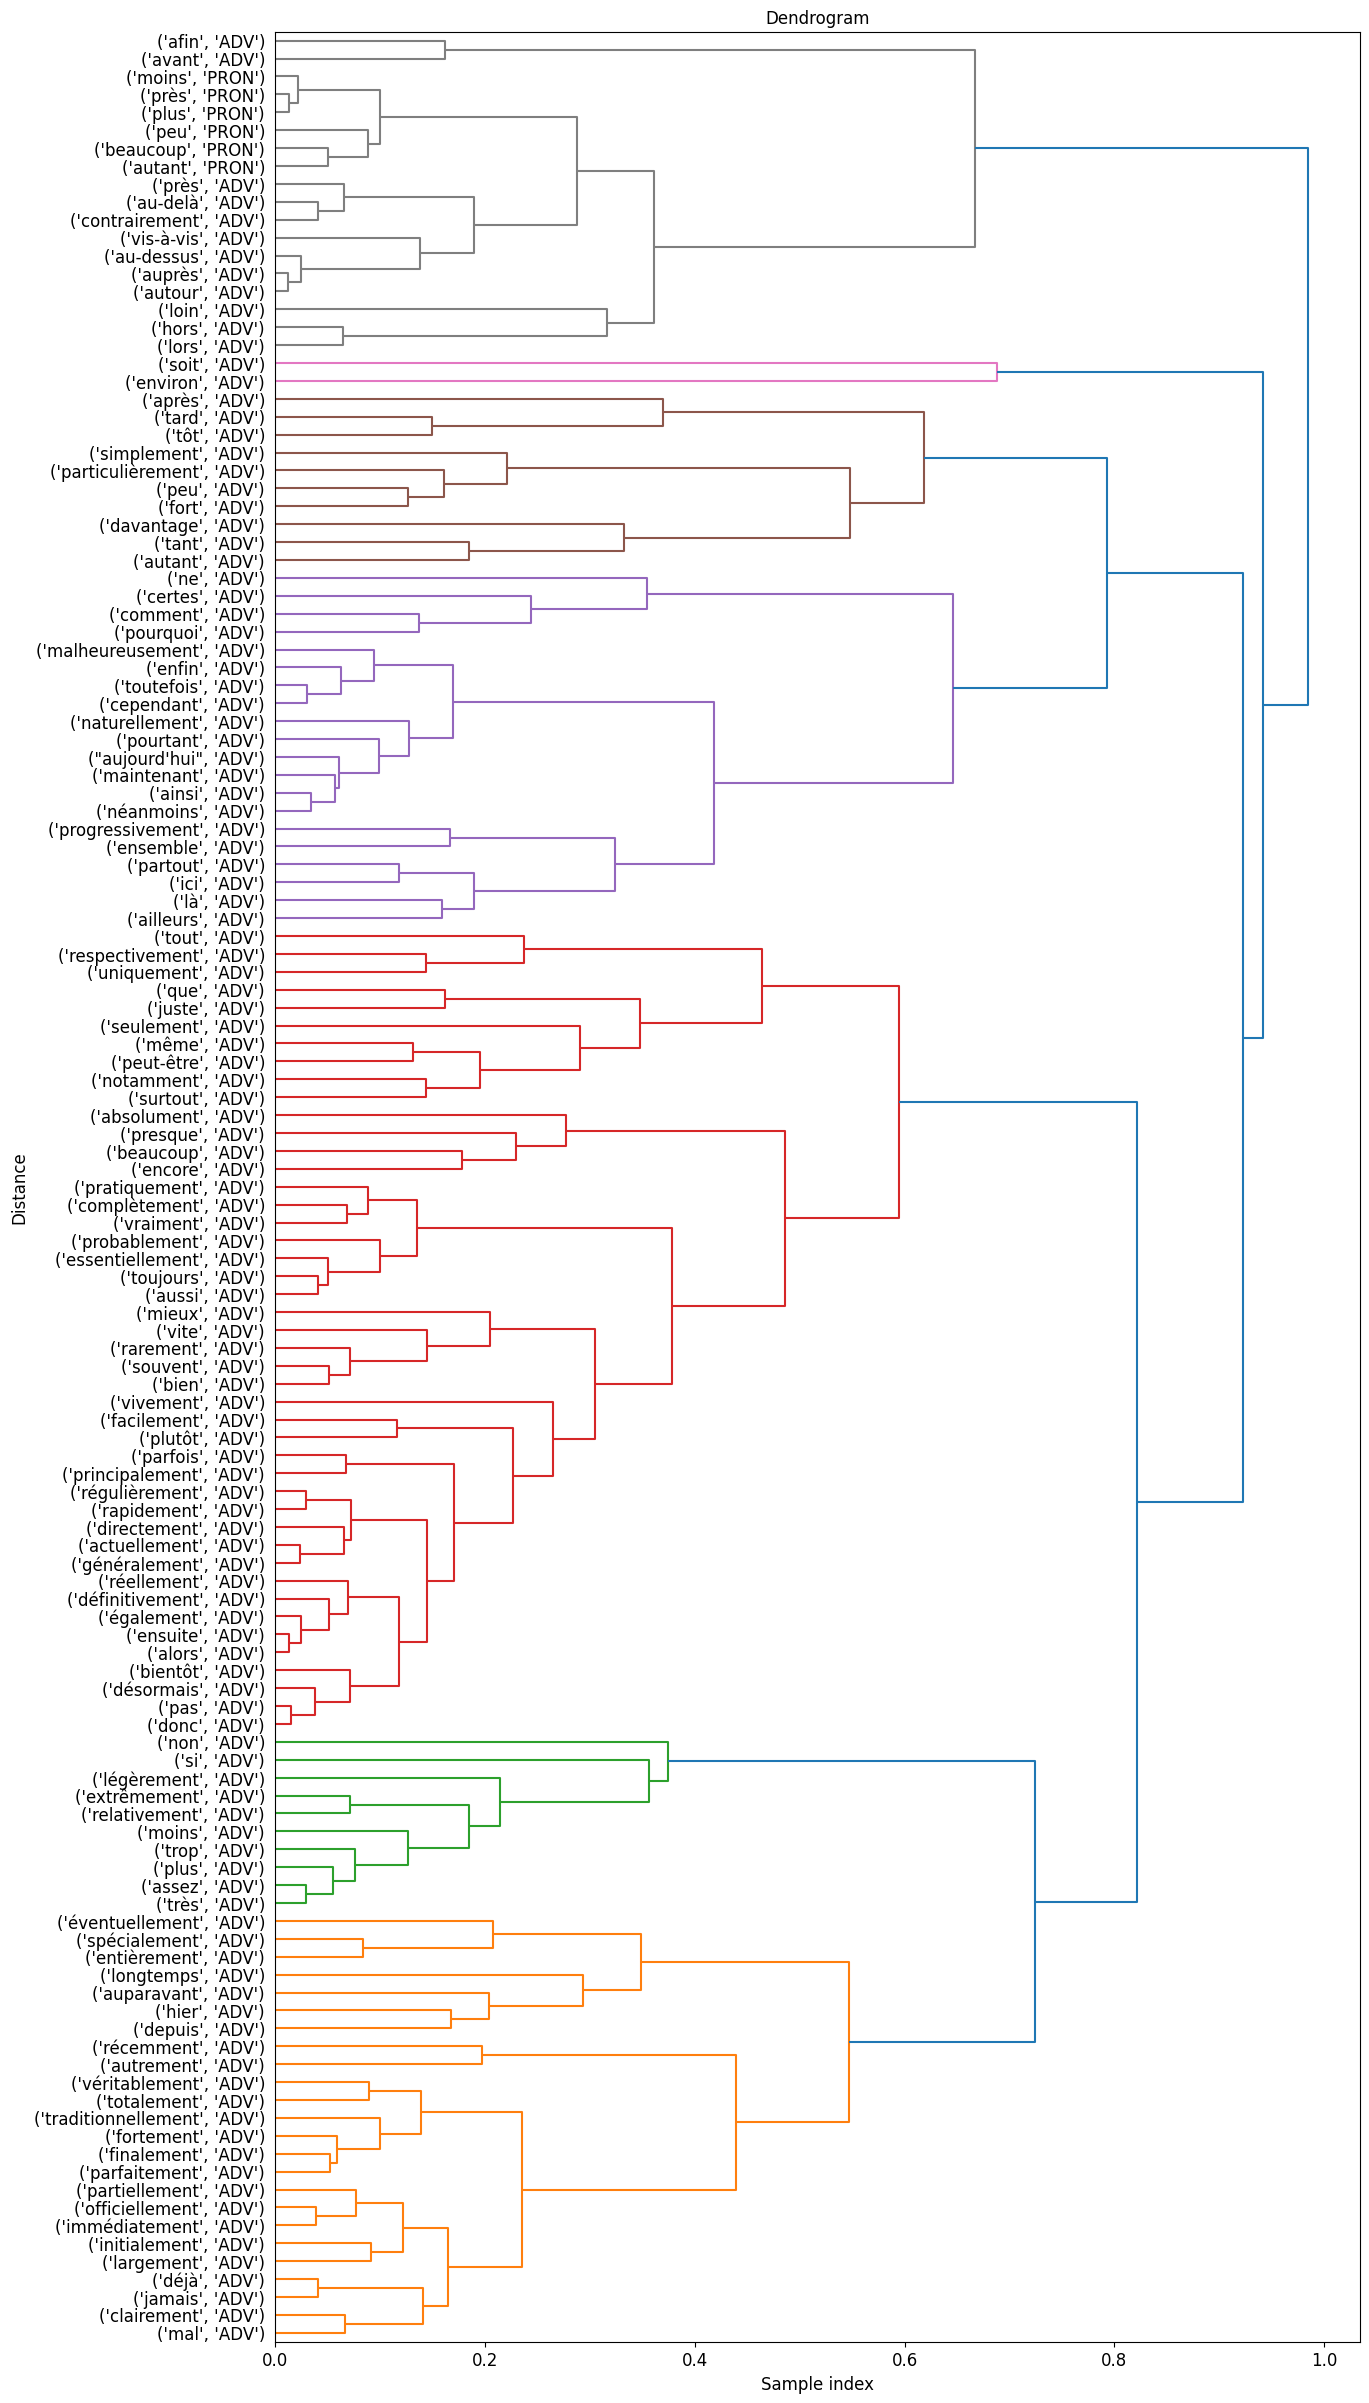

In [177]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

distance_matrix = pdist(X_final, metric="cosine")
linked = linkage(
            distance_matrix, method="complete", optimal_ordering=True
        ) 


plt.figure(figsize=(14, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X_final.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

In [179]:
with open('x_65dims.npy', 'wb') as f:
    np.save(f, X_final)